In [1]:
include("../resk.jl")
include("../reskplots.jl")

RESK successfully loaded.
RESKPlots successfully loaded.


In [2]:
test = deserialize("data/test_fst.re")

OrderedDict{String, Any} with 6 entries:
  "stats" => OrderedDict{String, Any}("name"=>"2024-11-15_05-46-05", "max"=>(7,…
  "fitn"  => Float32[NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN Na…
  "pops"  => Float32[NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN Na…
  "cAA"   => Float32[NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN Na…
  "cAa"   => Float32[NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN Na…
  "caa"   => Float32[NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN Na…

In [59]:
re_res,re_time = @timed rangeexp_cylinder(30,60,1;data_to_generate="FPC",z_max_burnin=4, z_max_exp=30,r_max_burnin=3,r_max_exp=3,bottleneck=NaN,capacity=35, prolif_rate=1.8, n_loci=1000,
n_sel_loci=312, mut_rate=1,migr_rate=0.145,sel_coef=0.01,multiproc=false)
re_time

MethodError: MethodError: no method matching *(::Float64, ::String)

Closest candidates are:
  *(::Any, ::Any, !Matched::Any, !Matched::Any...)
   @ Base operators.jl:587
  *(!Matched::Automa.RegExp.RE, ::Union{AbstractChar, AbstractString})
   @ Automa C:\Users\Hartree\.julia\packages\Automa\21Mvk\src\re.jl:268
  *(!Matched::ChainRulesCore.NoTangent, ::Any)
   @ ChainRulesCore C:\Users\Hartree\.julia\packages\ChainRulesCore\I1EbV\src\tangent_arithmetic.jl:64
  ...


30~40s and 8 GiB allocations to run ```test = @time rangeexp_cylinder(3,13,1;data_to_generate="FP",z_max_burnin=4, z_max_exp=30,r_max_burnin=3,bottleneck=NaN,capacity=35, prolif_rate=1.8, n_loci=1000,
n_sel_loci=312, mut_rate=1,migr_rate=0.145,sel_coef=0.01,multiproc=false)```. The resulting sizes are: "fitn" or "pops" -> 3 MB.


62s and allocations: 37.554 GiB to run ```test = @time rangeexp_cylinder(3,13,1;data_to_generate="FPC",z_max_burnin=4, z_max_exp=30,r_max_burnin=3,bottleneck=NaN,capacity=35, prolif_rate=1.8, n_loci=1000,
n_sel_loci=312, mut_rate=1,migr_rate=0.145,sel_coef=0.01,multiproc=false)```. The resulting sizes are: "fitn" or "pops" -> 3 MB, "cAA" etc each -> 3227 MB. So they take up ~9 GB of space aside from allocations

---

27s and 6.6 GiB allocations to run ```test = @time rangeexp_cylinder(3,13,1;data_to_generate="FP",z_max_burnin=4, z_max_exp=30,r_max_burnin=3,bottleneck=NaN,capacity=35, prolif_rate=1.8, n_loci=1000,
n_sel_loci=312, mut_rate=1,migr_rate=0.145,sel_coef=0.01,multiproc=false)```. The resulting sizes are: "fitn" or "pops" -> 94 KB.


30~40s and 8.5 GiB allocations to run ```test = @time rangeexp_cylinder(3,13,1;data_to_generate="FPC",z_max_burnin=4, z_max_exp=30,r_max_burnin=3,r_max_exp=3,bottleneck=NaN,capacity=35, prolif_rate=1.8, n_loci=1000,
n_sel_loci=312, mut_rate=1,migr_rate=0.145,sel_coef=0.01,multiproc=false)```. The resulting sizes are: "fitn" or "pops" -> 94 KB, "cAA" etc each -> 94 MB. So they take up ~290 MB of space aside from allocations

---

<448s and (5.66 G allocations: 98.278 GiB, 3.98% gc time) to run ```test = @time rangeexp_cylinder(15,20,1;data_to_generate="FPC",z_max_burnin=4, z_max_exp=30,r_max_burnin=3,r_max_exp=3,bottleneck=NaN,capacity=35, prolif_rate=1.8, n_loci=1000,
n_sel_loci=312, mut_rate=1,migr_rate=0.145,sel_coef=0.01,multiproc=false)```. The resulting sizes are: "fitn" or "pops" -> 205 KB, "cAA" etc each -> 205 MB.

In [4]:
sizeof(test["fitn"])

529200

In [8]:
re_heatstack(test,"fitn")

(0.8953835f0, 1.0f0)


"2024-12-08_08-38-04.mp4"

In [17]:
#test = rangeexp_strip(3,5,1;data_to_generate="FC",bottleneck=NaN,n_loci=110,mut_rate=0.8,multiproc=false)

(100, 10, 110, 8)
(100, 10, 110, 8)


OrderedDict{String, Any} with 5 entries:
  "stats" => OrderedDict{String, Any}("name"=>"2024-11-14_07-15-14", "max"=>(10…
  "fitn"  => Float32[NaN NaN … 1.0 NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN Na…
  "cAA"   => Float32[NaN NaN … 0.0 NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN Na…
  "cAa"   => Float32[NaN NaN … 0.0 NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN Na…
  "caa"   => Float32[NaN NaN … 1.0 NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN Na…

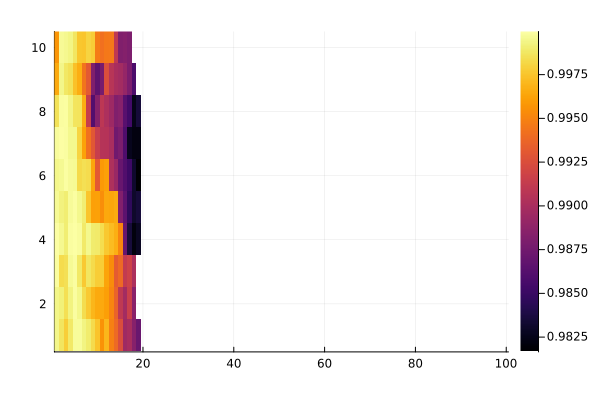

In [17]:
Plots.heatmap(test["fitn"][:,:,end,1]')

In [50]:
#(2*re["cAA"][1,1,1,70,1]+re["cAa"][deme...,locus,gen,re_index])/re["stats"]["n_loci"]
mean(af_A(test,(4,4,1),1:test["stats"]["n_loci"]))

6.261803f-6

In [51]:
H_11 = twopq(test,(4,4,1))

1.2522251f-5

In [7]:
test["caa"][10,5,1,150,1]

0.96825397f0

In [52]:
H_end = mean([twopq(test,(4,4,4),i) for i in 1:test["stats"]["n_loci"]])

8.462797f-6

In [6]:
saisho_to_saigo = [(4,4,1),(4,4,19)]#[(1,1),(10,5)]
F_ST(test,saisho_to_saigo,1:test["stats"]["n_loci"])

5.9154077e-5
5.9122496e-5


0.00053388195f0